In [13]:
import pandas as pd
import sqlalchemy as sa
import urllib
import matplotlib.pyplot as plt
import seaborn as sns




In [14]:

# Define your connection parameters
params = urllib.parse.quote_plus(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=localhost;"  # Or your specific IP address
    "Database=banking_cases;"
    "UID=sa;"            # Default user for Docker MSSQL
    "PWD=Password92;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

# Create the engine
engine = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print(engine)

df = pd.read_sql("SELECT * FROM customer", engine)
df.head()

Engine(mssql+pyodbc:///?odbc_connect=Driver%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BServer%3Dlocalhost%3BDatabase%3Dbanking_cases%3BUID%3Dsa%3BPWD%3DPassword92%3BEncrypt%3Dyes%3BTrustServerCertificate%3Dyes%3B)


,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1.485829e+06,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,6.414828e+05,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1.033402e+06,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.877825e+05,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,1,2,5


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client_ID                 3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location_ID               3000 non-null   int64  
 4   Joined_Bank               3000 non-null   object 
 5   Banking_Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee_Structure             3000 non-null   str    
 9   Loyalty_Classification    3000 non-null   str    
 10  Estimated_Income          3000 non-null   float64
 11  Superannuation_Savings    3000 non-null   float64
 12  Amount_of_Credit_Cards    3000 non-null   int64  
 13  Credit_Card_Balance       3000 non-null   float64
 14  Bank_Loans         

In [16]:
df.describe()

,Age,Location_ID,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034184,25531.599685,1.463667,3176.206944,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529998,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808180,16259.950768,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924033,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480469,1482.030029,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.597656,12513.774902,1.000000,1236.630005,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542236,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.476562,22357.355469,1.000000,2560.804932,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190430,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.300781,35464.741211,2.000000,4522.632690,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.391602,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.250000,75963.898438,3.000000,13991.990234,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.867188,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [17]:
 df.columns = df.columns.str.lower()

In [18]:
df

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1.485829e+06,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,6.414828e+05,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1.033402e+06,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.877825e+05,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,2014-10-09,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1.089957e+06,5.328679e+05,657849.625000,12947.309570,1.238860e+06,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,2009-02-05,Dennis Ruiz,European,Paralegal,Mid,Gold,...,1.368913e+05,5.658174e+04,93195.609375,23205.689453,2.771711e+05,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,2009-12-29,Joshua Ryan,American,Statistician IV,Low,Jade,...,2.148609e+05,1.587261e+05,35539.148438,30291.810547,5.029472e+05,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,2006-02-13,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,7.426302e+05,4.046382e+05,56411.328125,6413.140137,1.538369e+06,3,1,3,2,7


In [19]:
icome_bins = [0,100000,300000,float('inf')]
labels=['Low','Medium','High']
df['income_band']=pd.cut(df['estimated_income'],bins=icome_bins,labels=labels,right=False)

In [20]:
df['income_band'].value_counts()

income_band
Medium    1517
Low       1027
High       456
Name: count, dtype: int64

<Axes: xlabel='income_band'>

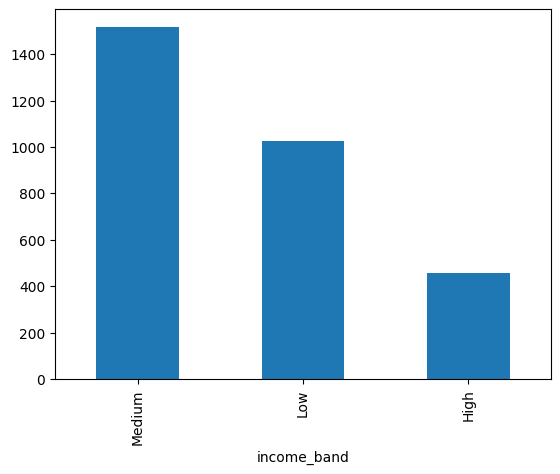

In [21]:
df['income_band'].value_counts().plot(kind='bar')

In [22]:
 df.columns

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'income_band'],
      dtype='str')

In [23]:
categorical_coluumns = df[['brid', 'genderid', 'iaid', 'amount_of_credit_cards', 'nationality', 'occupation', 'fee_structure', 'properties_owned', 'loyalty_classification', 'risk_weighting', 'income_band']].columns

for cols in categorical_coluumns:
    print(f"Value counts for '{cols}':")
    display(df[cols].value_counts() )
    print("\n\n\n\n")

Value counts for 'brid':


brid
3    1352
1     660
2     495
4     493
Name: count, dtype: int64






Value counts for 'genderid':


genderid
2    1512
1    1488
Name: count, dtype: int64






Value counts for 'iaid':


...

loyalty_classification
Jade        1331
Silver       767
Gold         585
Platinum     317
Name: count, dtype: int64






Value counts for 'risk_weighting':


risk_weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64






Value counts for 'income_band':


income_band
Medium    1517
Low       1027
High       456
Name: count, dtype: int64

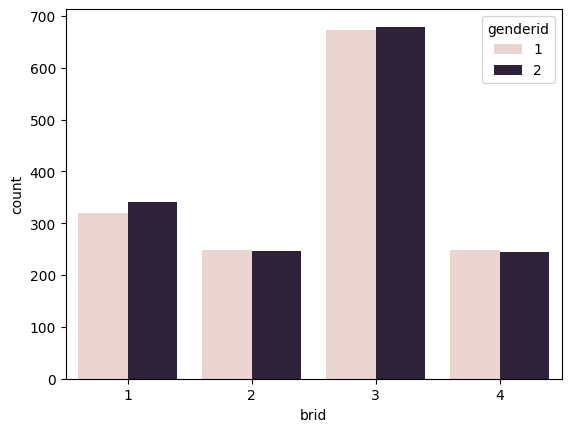

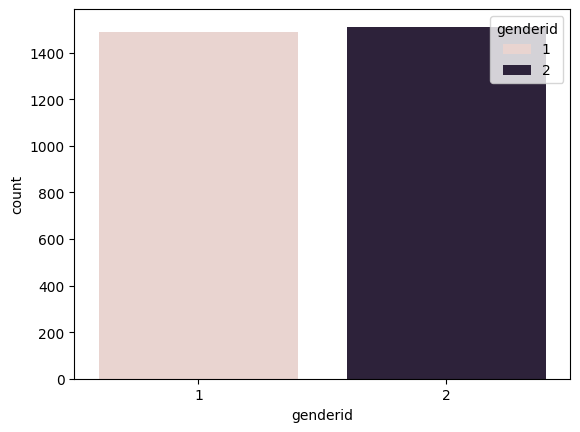

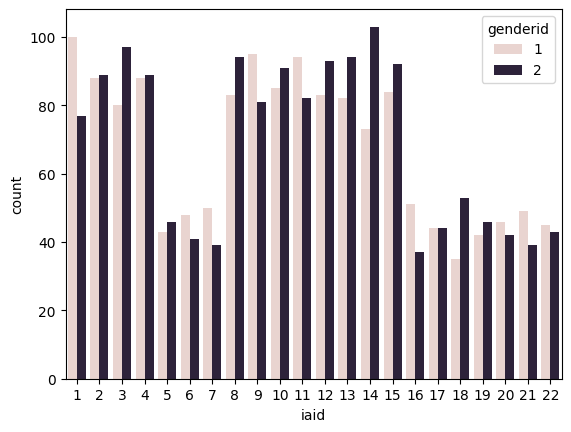

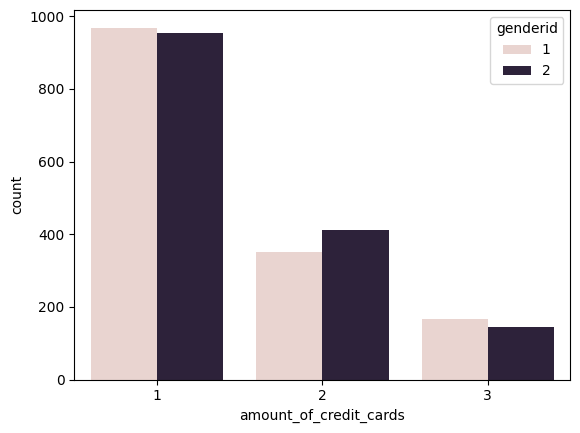

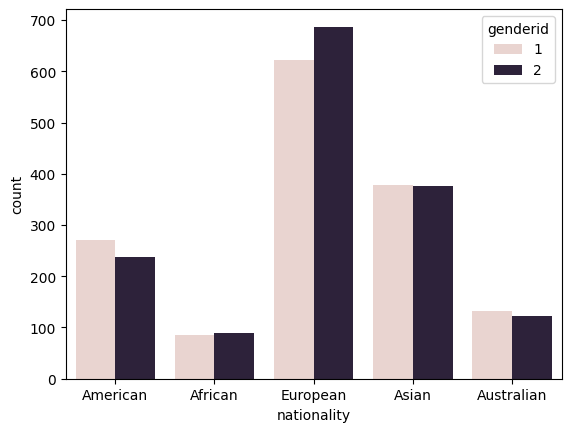

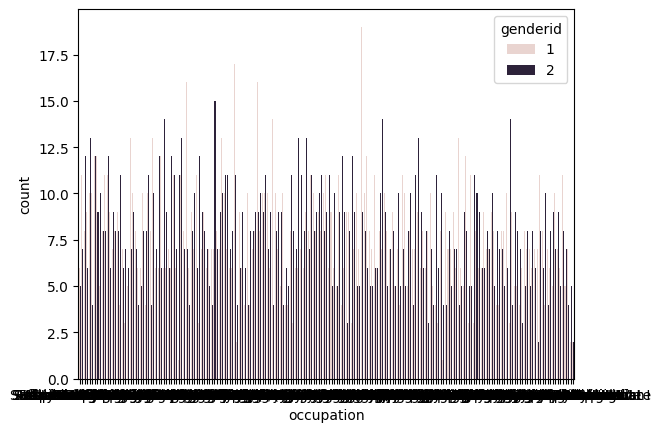

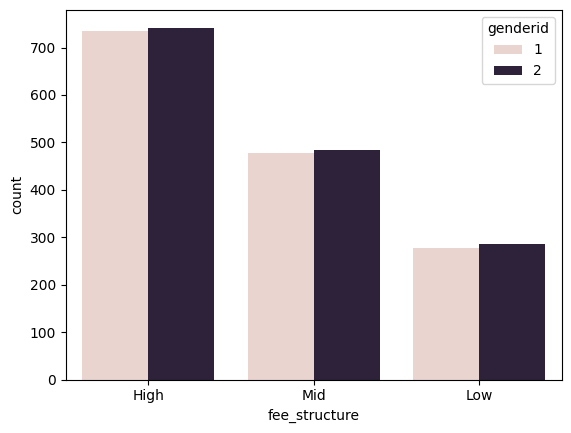

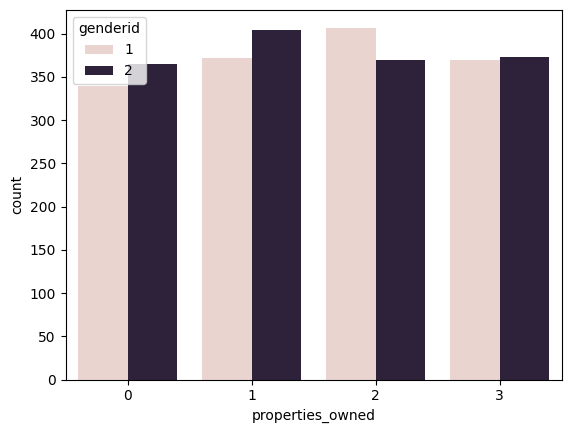

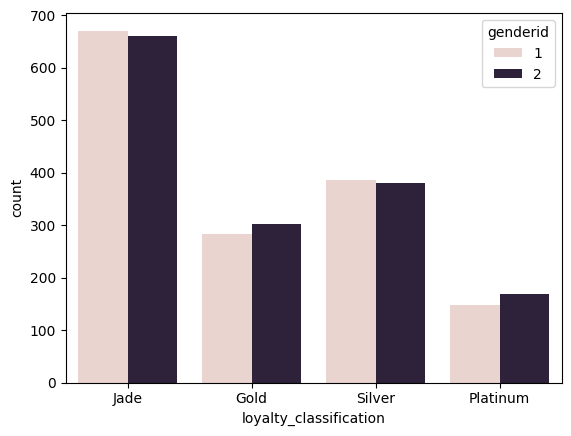

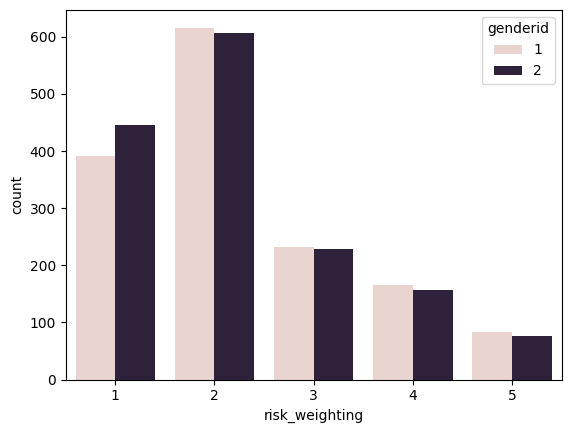

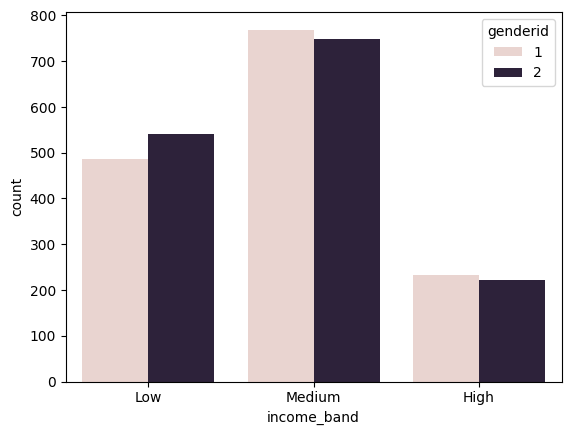

In [24]:
for i, predictor in enumerate(categorical_coluumns):
   plt.figure(i)
   sns.countplot(data=df, x=predictor, hue='genderid' )

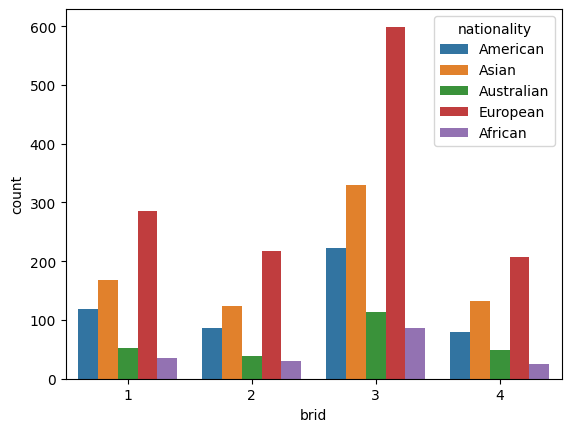

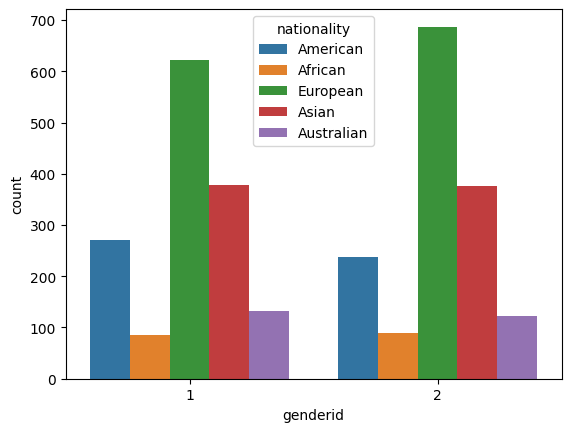

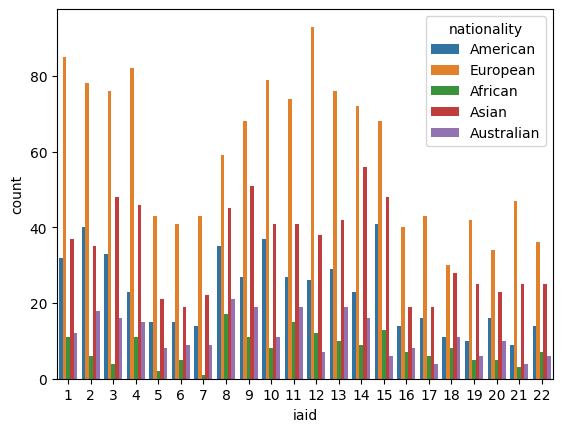

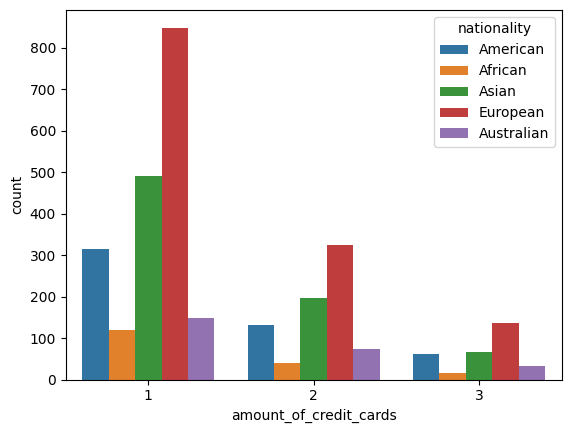

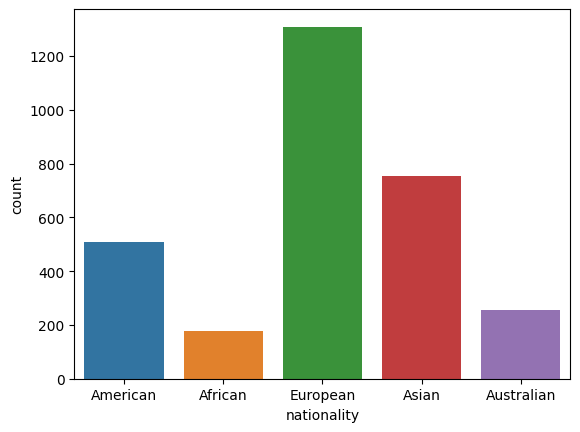

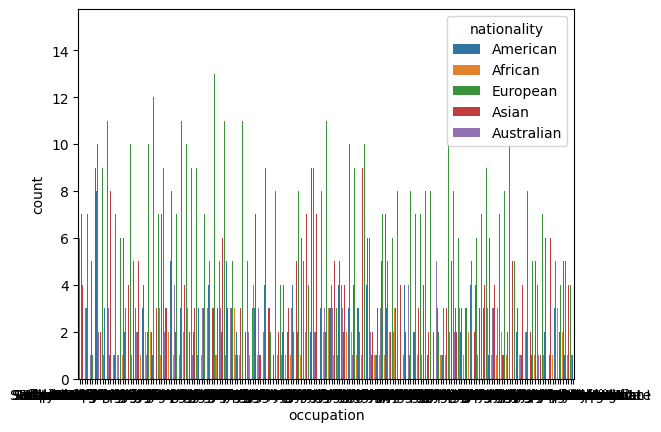

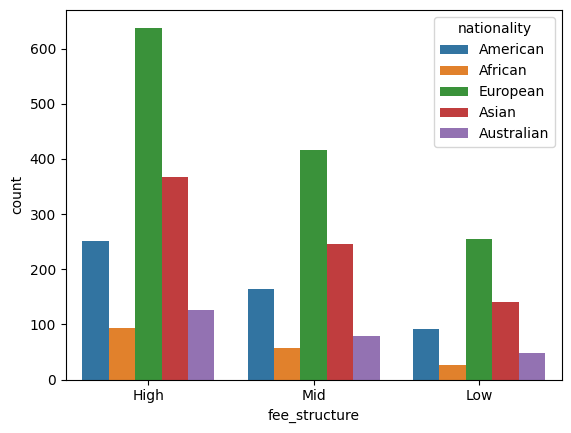

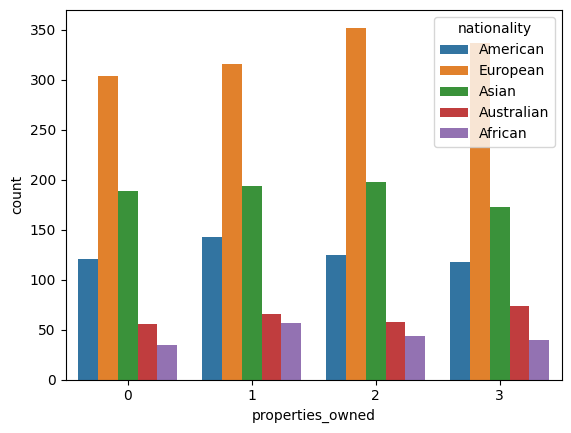

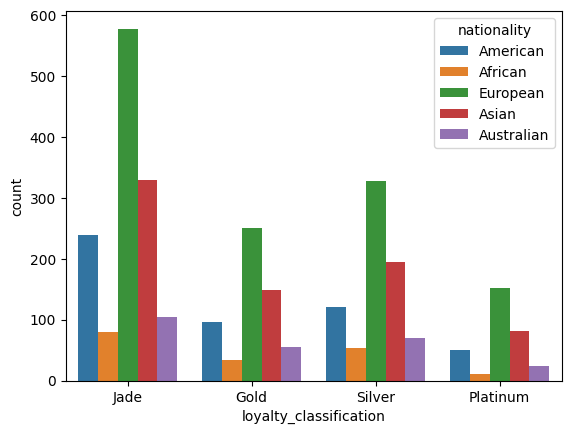

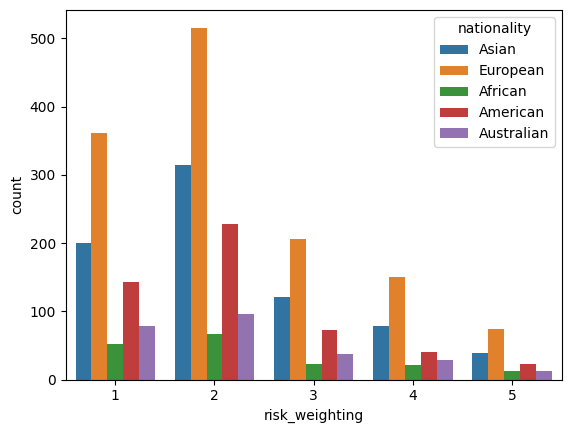

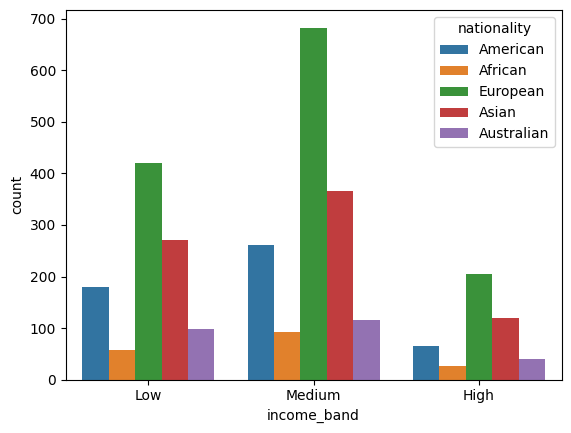

In [25]:
for i, predictor in enumerate(categorical_coluumns):
   plt.figure(i)
   sns.countplot(data=df, x=predictor, hue='nationality' )

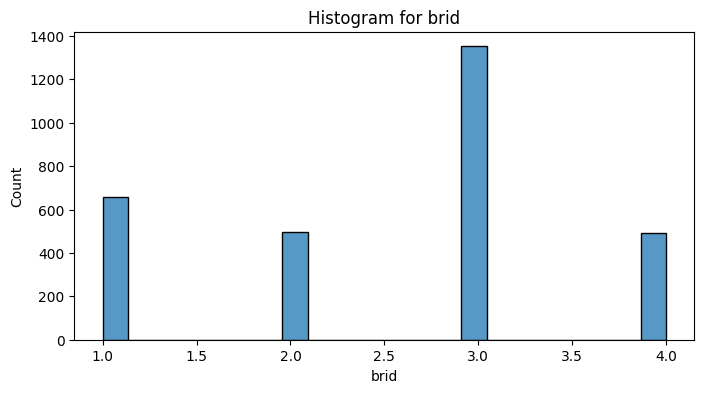

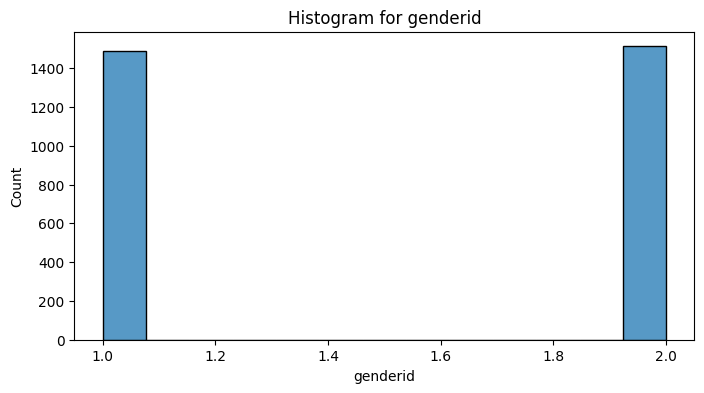

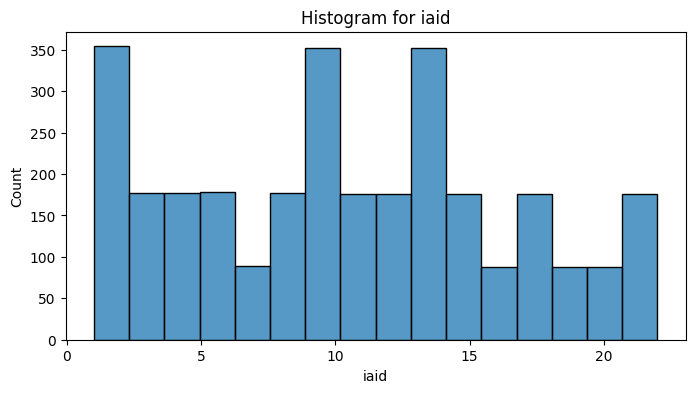

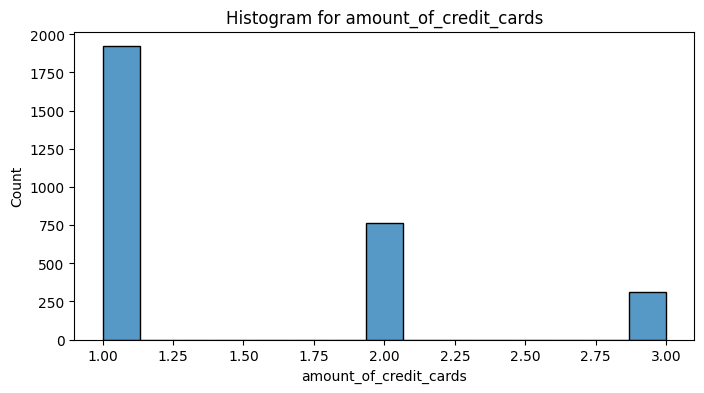

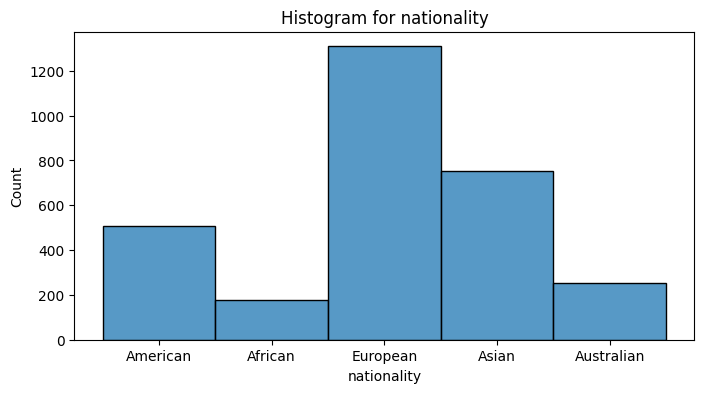

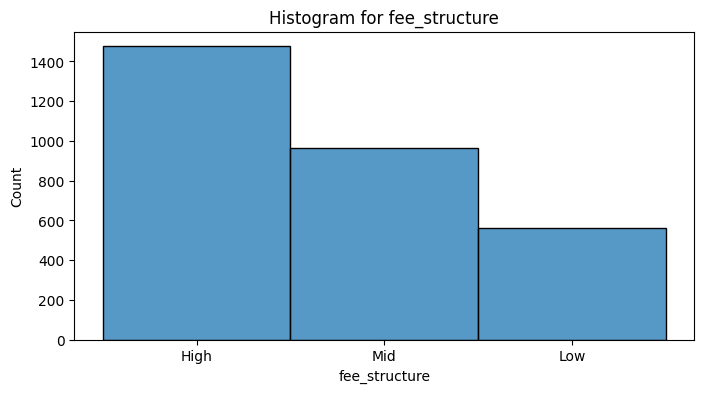

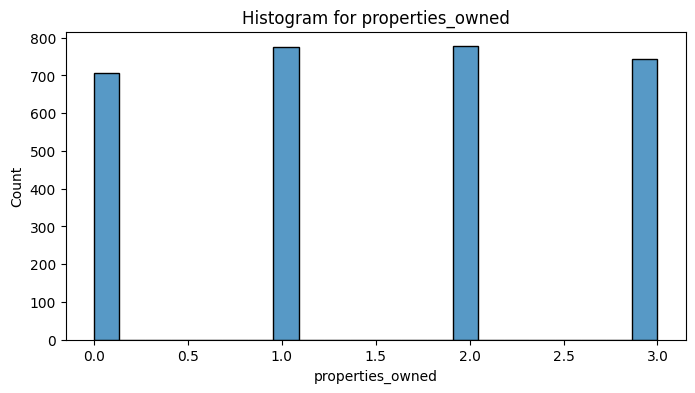

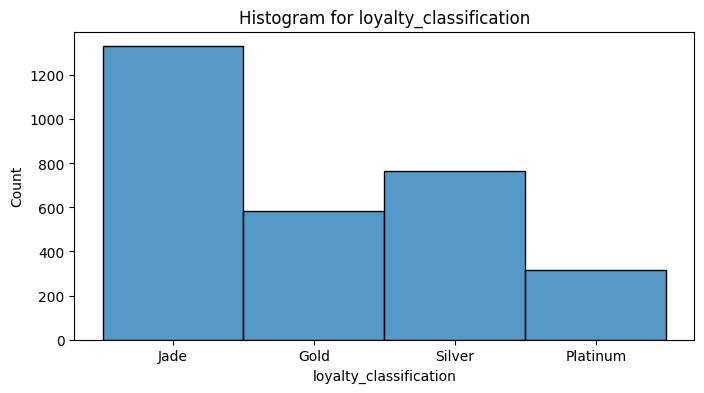

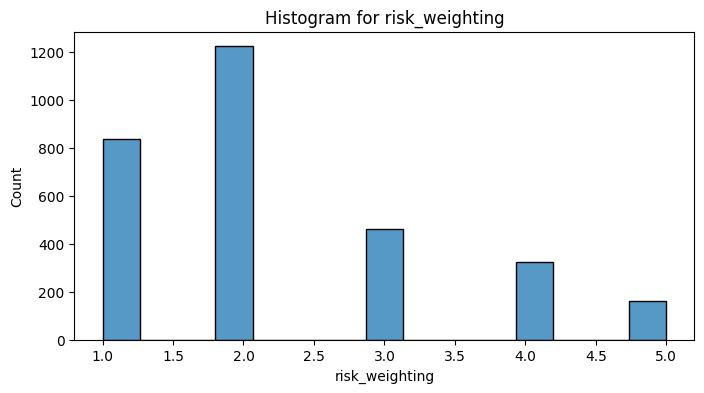

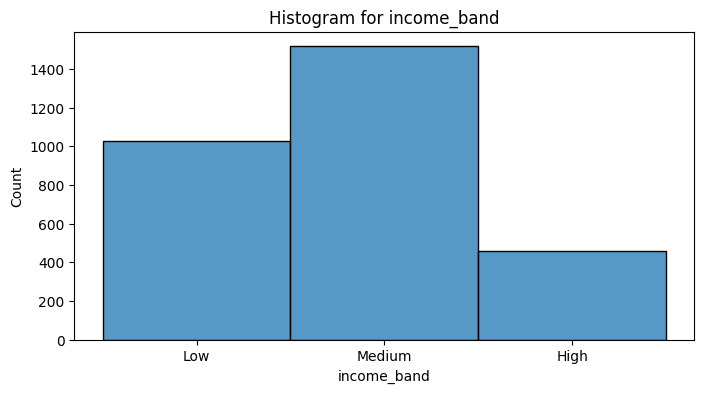

In [39]:
for cols in categorical_coluumns:
    if cols == 'occupation':
        continue
    plt.figure(figsize = (8,4))
    sns.histplot(df[cols])
    plt.title(f"Histogram for {cols}")
    plt.xlabel(cols)
    plt.ylabel("Count")
    plt.show()

In [40]:
df.columns

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'income_band'],
      dtype='str')

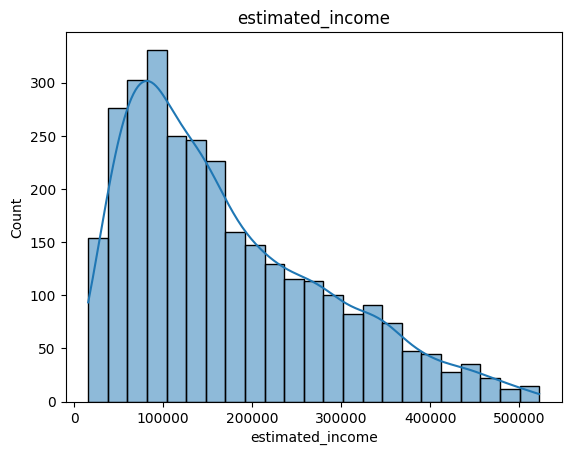

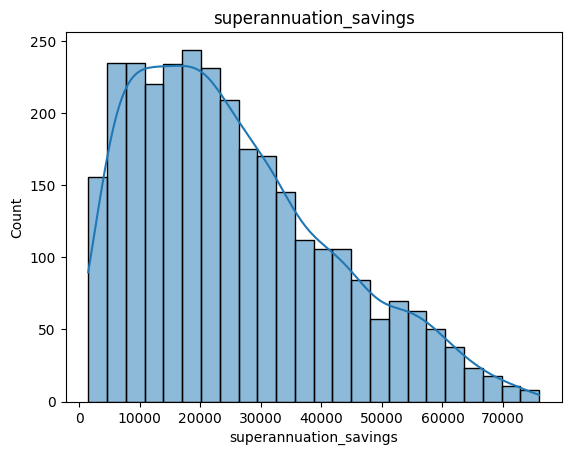

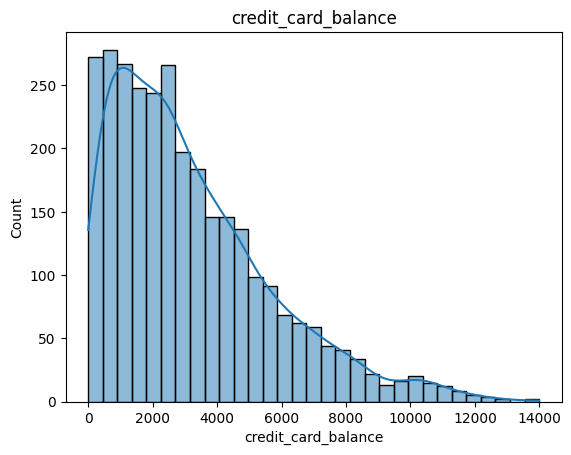

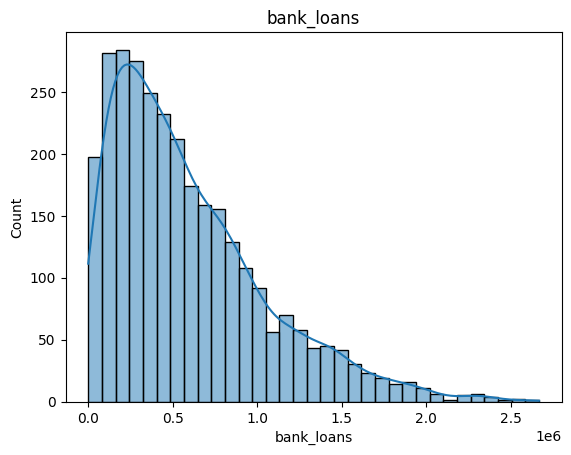

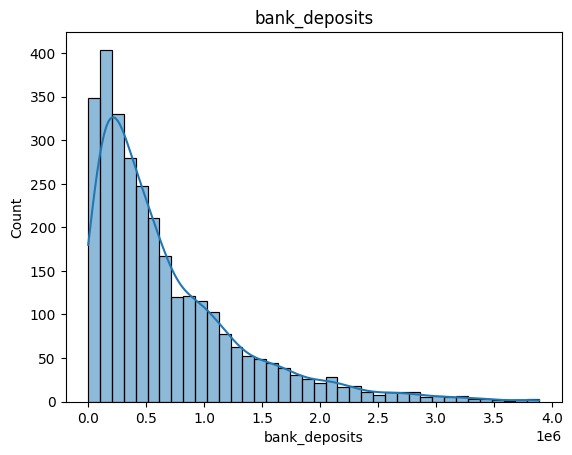

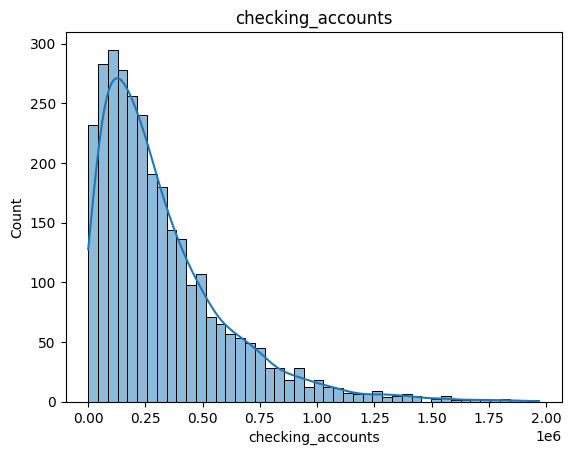

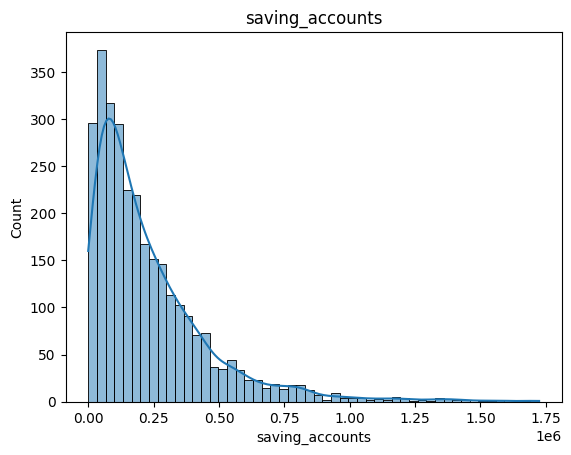

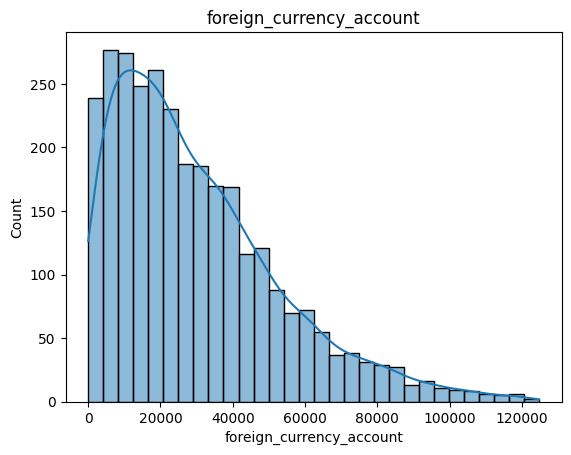

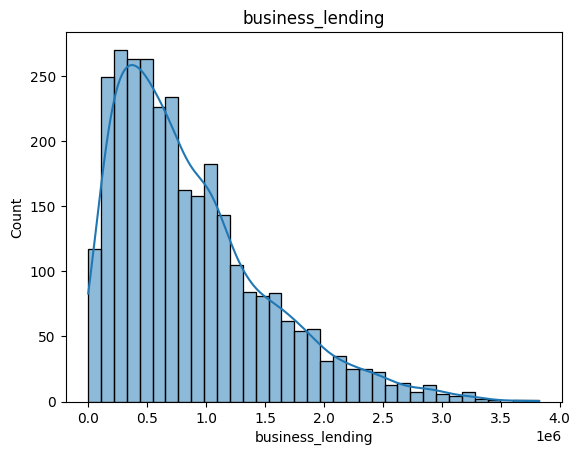

In [70]:
numerical_columns = df[['estimated_income', 'superannuation_savings','credit_card_balance', 'bank_loans','bank_deposits', 'checking_accounts', 'saving_accounts', 'foreign_currency_account', 'business_lending']].columns
for i, predictor in enumerate(numerical_columns):
    
    sns.histplot(df[predictor], kde = True)
    plt.title(predictor)
    plt.show()

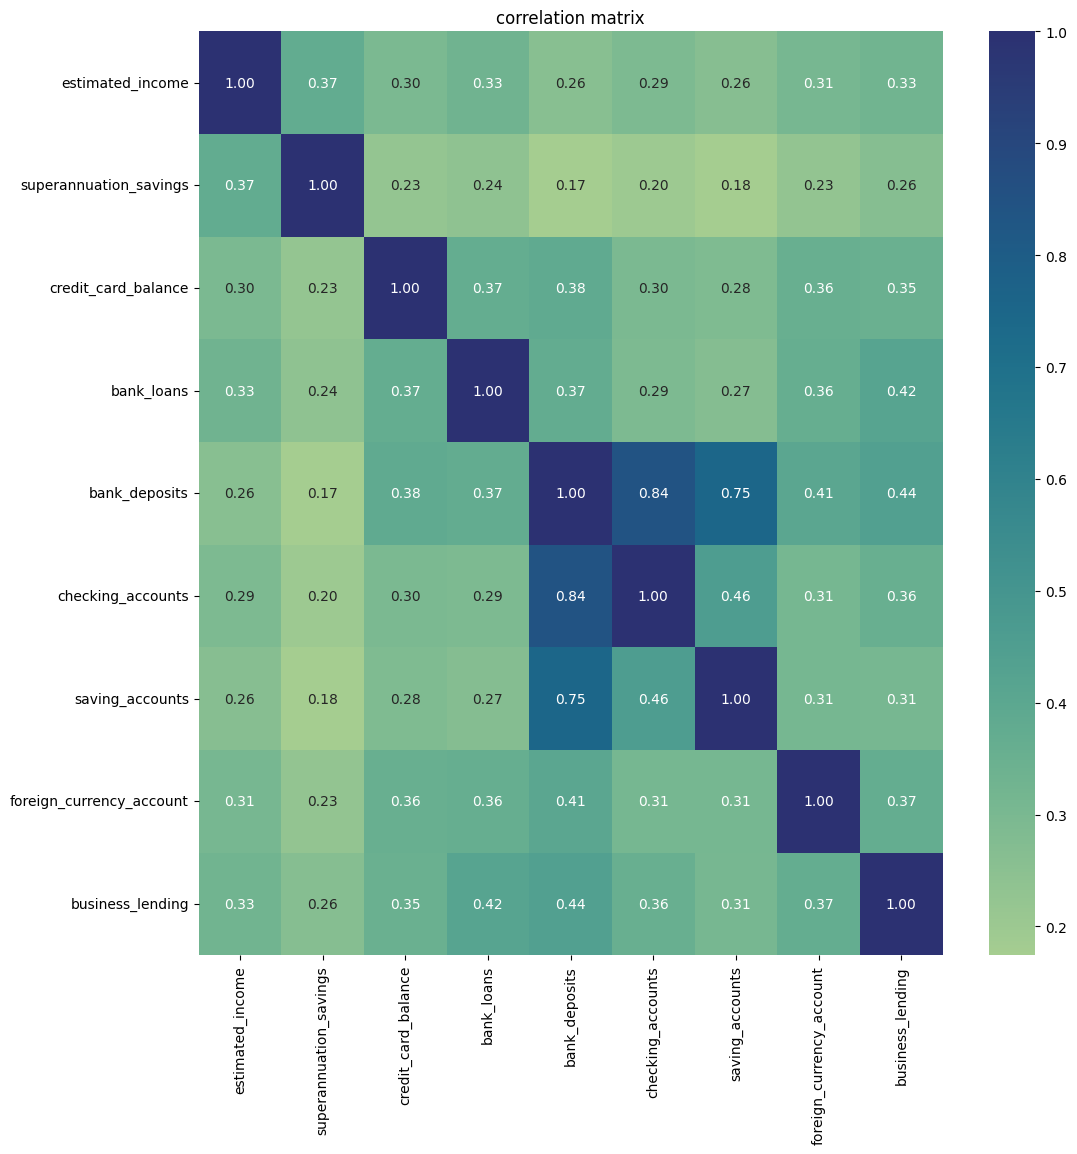

In [72]:
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize = (12,12))
sns.heatmap(correlation_matrix, annot= True, cmap = 'crest', fmt = ".2f")
plt.title("correlation matrix")
plt.show()